In [39]:
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import ast
import seaborn as sns

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval (x) if pd.notna(x) else x)


In [91]:
df_ind_da = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'India')].copy()
df_ind_da['job_posted_month']= df['job_posted_date'].dt.month
df_ind_da_explode = df_ind_da.explode('job_skills')
df_pivot = df_ind_da_explode.pivot_table(index='job_posted_month', columns= 'job_skills', aggfunc='size', fill_value=0)
df_pivot.loc['total']= df_pivot.sum()
df_pivot = df_pivot[df_pivot.loc['total'].sort_values(ascending=False).head().index]
df_pivot= df_pivot.drop('total')



In [92]:
da_total = df_ind_da.groupby('job_posted_month').size()
df_per = df_pivot.div(da_total/100, axis=0)
df_per

job_skills,sql,python,excel,tableau,power bi
job_posted_month,,,,,
1,48.566879,34.394904,34.713376,25.318471,15.605096
2,48.267898,34.180139,36.027714,26.789838,17.321016
3,54.265403,35.781991,32.701422,29.620853,18.009479
4,48.803828,34.210526,33.014354,23.444976,19.856459
5,55.755396,36.330935,38.129496,25.539568,21.942446
6,52.588556,40.871935,31.335150,31.062670,20.980926
7,53.610503,35.229759,38.074398,27.133479,20.350109
8,51.294498,34.951456,31.067961,24.595469,20.550162
9,54.126984,36.349206,36.190476,30.952381,26.666667


In [93]:
df_per = df_per.reset_index()
df_per

job_skills,job_posted_month,sql,python,excel,tableau,power bi
0,1,48.566879,34.394904,34.713376,25.318471,15.605096
1,2,48.267898,34.180139,36.027714,26.789838,17.321016
2,3,54.265403,35.781991,32.701422,29.620853,18.009479
3,4,48.803828,34.210526,33.014354,23.444976,19.856459
4,5,55.755396,36.330935,38.129496,25.539568,21.942446
5,6,52.588556,40.871935,31.335150,31.062670,20.980926
6,7,53.610503,35.229759,38.074398,27.133479,20.350109
7,8,51.294498,34.951456,31.067961,24.595469,20.550162
8,9,54.126984,36.349206,36.190476,30.952381,26.666667
9,10,53.800000,37.000000,38.600000,30.600000,22.000000


In [94]:
df_per['j_m'] = df_per['job_posted_month'].apply(lambda x: pd.to_datetime(x, format='%m').strftime('%b'))
df_per = df_per.set_index('j_m')
df_per = df_per.drop(columns= 'job_posted_month')
df_per

job_skills,sql,python,excel,tableau,power bi
j_m,,,,,
Jan,48.566879,34.394904,34.713376,25.318471,15.605096
Feb,48.267898,34.180139,36.027714,26.789838,17.321016
Mar,54.265403,35.781991,32.701422,29.620853,18.009479
Apr,48.803828,34.210526,33.014354,23.444976,19.856459
May,55.755396,36.330935,38.129496,25.539568,21.942446
Jun,52.588556,40.871935,31.335150,31.062670,20.980926
Jul,53.610503,35.229759,38.074398,27.133479,20.350109
Aug,51.294498,34.951456,31.067961,24.595469,20.550162
Sep,54.126984,36.349206,36.190476,30.952381,26.666667


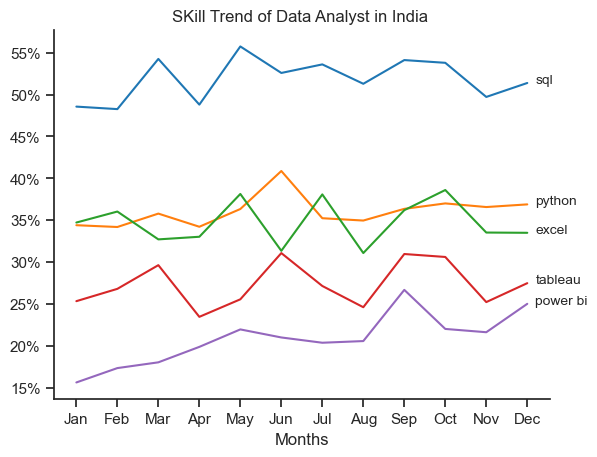

In [119]:
sns.lineplot(data=df_per, dashes=False, palette='tab10', linewidth=1.5)
sns.set_theme(style='ticks')
sns.despine()
plt.title('SKill Trend of Data Analyst in India ')
plt.ylabel('')
plt.xlabel('Months')
plt.legend().remove()

from matplotlib.ticker import PercentFormatter  
ax=plt.gca()
ax.yaxis.set_major_formatter(PercentFormatter(decimals=0))

for i in range (5):
    plt.text(11.2, df_per.iloc[-1, i], df_per.columns[i], fontsize=10)
plt.show()